In [2]:
# Install the Kaggle library to download datasets directly.
!pip install kaggle

In [3]:
# Upload your Kaggle API token file.
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yelzhasomarov","key":"2891a881fa4910b78786bc7ae928b4c8"}'}

In [4]:
# Set up the Kaggle directory and move the token file there.
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# Download the dataset from Kaggle.
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images

# Unzip the downloaded file.
!unzip chest-ctscan-images.zip

Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
 67% 79.0M/119M [00:00<00:00, 822MB/s]
100% 119M/119M [00:00<00:00, 849MB/s] 
Archive:  chest-ctscan-images.zip
  inflating: Data/test/adenocarcinoma/000108 (3).png  
  inflating: Data/test/adenocarcinoma/000109 (2).png  
  inflating: Data/test/adenocarcinoma/000109 (4).png  
  inflating: Data/test/adenocarcinoma/000109 (5).png  
  inflating: Data/test/adenocarcinoma/000112 (2).png  
  inflating: Data/test/adenocarcinoma/000113 (7).png  
  inflating: Data/test/adenocarcinoma/000114 (5).png  
  inflating: Data/test/adenocarcinoma/000114.png  
  inflating: Data/test/adenocarcinoma/000115 (4).png  
  inflating: Data/test/adenocarcinoma/000115 (8).png  
  inflating: Data/test/adenocarcinoma/000115.png  
  inflating: Data/test/adenocarcinoma/000116 (5).png  
  inflating: Data/test/adenocarcinoma/000116 (7).png  
  inflating: Data/test/adenocarcinoma/000116 (9).png  
  inflating: Data/test/ade

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
from sklearn.metrics import roc_auc_score
import time
import os
import copy

# Required imports for confusion matrix, t-SNE, and F1 score
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

In [7]:
# Data augmentation and normalization for training
# Just normalization for validation and test
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'Data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'valid', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32,
                             shuffle=True, num_workers=4)
               for x in ['train', 'valid', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
# Load ResNet-18 pretrained model
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Replace the final layer with a new one for 4 classes
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Optimize all parameters
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.005, momentum=0.9)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [9]:
def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [10]:
model_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=50)

Epoch 0/49
----------
train Loss: 1.1364 Acc: 0.4747
valid Loss: 1.3817 Acc: 0.3889

Epoch 1/49
----------
train Loss: 0.9243 Acc: 0.6150
valid Loss: 1.0596 Acc: 0.6111

Epoch 2/49
----------
train Loss: 0.8098 Acc: 0.6591
valid Loss: 0.9209 Acc: 0.7222

Epoch 3/49
----------
train Loss: 0.6887 Acc: 0.6982
valid Loss: 0.9895 Acc: 0.6806

Epoch 4/49
----------
train Loss: 0.8921 Acc: 0.6493
valid Loss: 1.6073 Acc: 0.4722

Epoch 5/49
----------
train Loss: 0.8131 Acc: 0.7439
valid Loss: 1.0463 Acc: 0.7361

Epoch 6/49
----------
train Loss: 0.5589 Acc: 0.7765
valid Loss: 1.2668 Acc: 0.6944

Epoch 7/49
----------
train Loss: 0.4459 Acc: 0.8336
valid Loss: 0.7856 Acc: 0.7917

Epoch 8/49
----------
train Loss: 0.4357 Acc: 0.8303
valid Loss: 1.1670 Acc: 0.7361

Epoch 9/49
----------
train Loss: 0.4301 Acc: 0.8336
valid Loss: 0.8458 Acc: 0.7083

Epoch 10/49
----------
train Loss: 0.5682 Acc: 0.7912
valid Loss: 0.8710 Acc: 0.8333

Epoch 11/49
----------
train Loss: 0.4375 Acc: 0.8434
valid Loss

In [11]:
# Evaluate on train and test sets, collect predictions and features for confusion matrix, F1 score, and t-SNE
model_ft.eval()

# Explicitly define datasets as a list to avoid namespace conflicts
dataset_phases = ['train', 'test']  # Renamed to avoid potential conflict with torchvision.datasets

# Initialize dictionaries for train and test datasets
all_y_true = {phase: [] for phase in dataset_phases}
all_y_pred = {phase: [] for phase in dataset_phases}
all_y_scores = {phase: [] for phase in dataset_phases}
all_features = {phase: [] for phase in dataset_phases}

for phase in dataset_phases:
    with torch.no_grad():
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Extract features from the second-to-last layer (before the final fc layer)
            x = model_ft.conv1(inputs)
            x = model_ft.bn1(x)
            x = model_ft.relu(x)
            x = model_ft.maxpool(x)
            x = model_ft.layer1(x)
            x = model_ft.layer2(x)
            x = model_ft.layer3(x)
            x = model_ft.layer4(x)
            x = model_ft.avgpool(x)
            x = torch.flatten(x, 1)
            all_features[phase].append(x.cpu().numpy())

            outputs = model_ft(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_y_true[phase].extend(labels.cpu().numpy())
            all_y_pred[phase].extend(preds.cpu().numpy())
            all_y_scores[phase].extend(probs.cpu().numpy())

# Convert lists to numpy arrays
for phase in dataset_phases:
    all_y_true[phase] = np.array(all_y_true[phase])
    all_y_pred[phase] = np.array(all_y_pred[phase])
    all_y_scores[phase] = np.array(all_y_scores[phase])
    all_features[phase] = np.concatenate(all_features[phase], axis=0)

# Compute F1 score (macro average) for test set
f1 = f1_score(all_y_true['test'], all_y_pred['test'], average='macro')
print(f'Test Macro F1 Score: {f1:.4f}')

# Compute AUC for each class on test set
auc_values = []
for i in range(len(class_names)):
    auc = roc_auc_score((all_y_true['test'] == i).astype(int), all_y_scores['test'][:, i])
    auc_values.append(auc)
print('Test AUC per class:', dict(zip(class_names, auc_values)))

# Compute confusion matrix for test set
cm = confusion_matrix(all_y_true['test'], all_y_pred['test'])

Test Macro F1 Score: 0.9366
Test AUC per class: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': np.float64(0.9754700854700854), 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': np.float64(0.9902703505644682), 'normal': np.float64(0.9989357173265219), 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': np.float64(0.9912592592592593)}


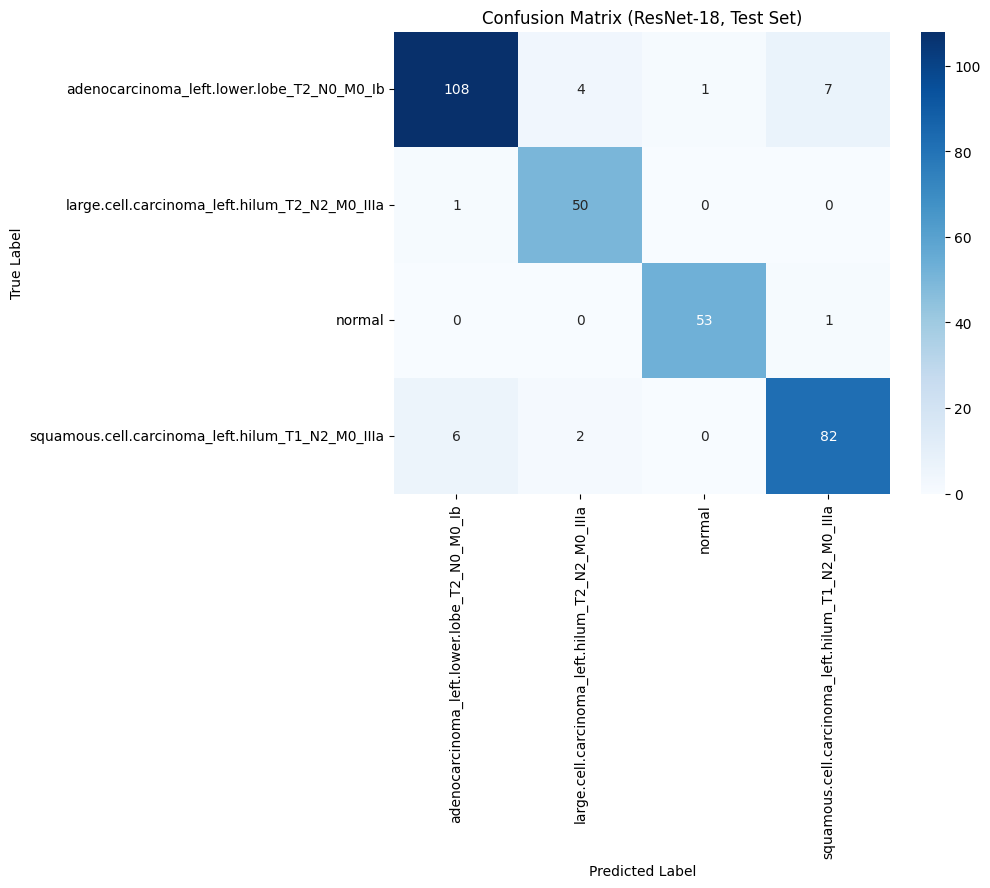

In [12]:
# Plot confusion matrix for test set using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (ResNet-18, Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

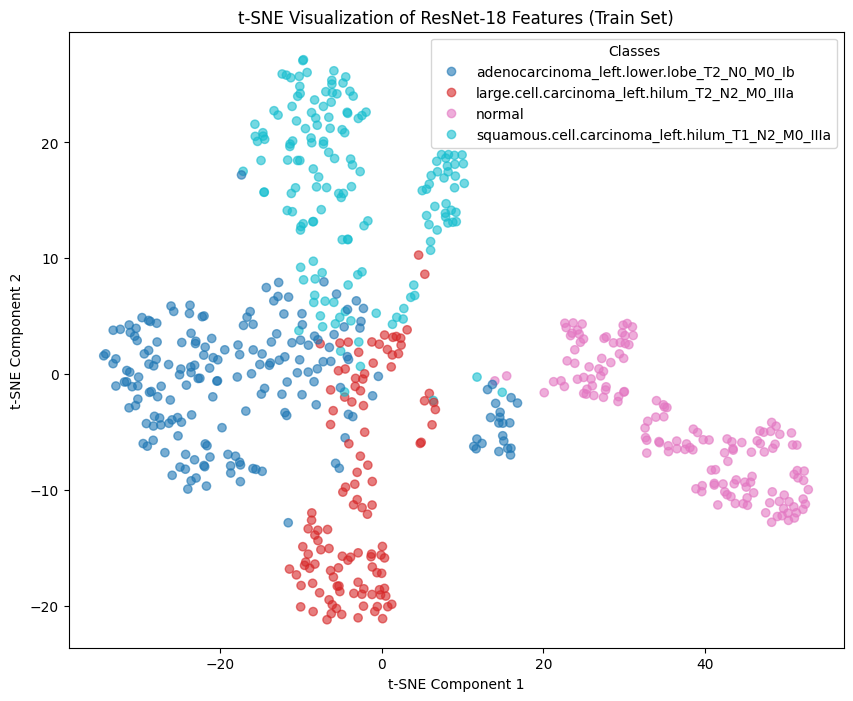

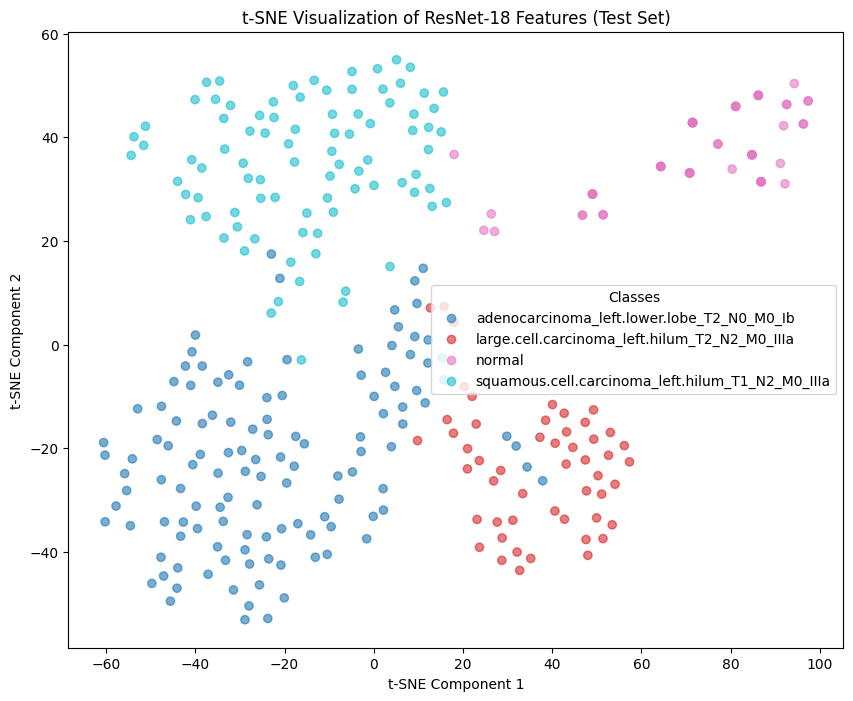

In [13]:
# t-SNE visualization for train and test datasets
for phase in dataset_phases:  # Use the explicitly defined dataset_phases
    tsne = TSNE(n_components=2, random_state=42)
    tsne_features = tsne.fit_transform(all_features[phase])

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=all_y_true[phase], cmap='tab10', alpha=0.6)
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Classes")
    plt.title(f't-SNE Visualization of ResNet-18 Features ({phase.capitalize()} Set)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1781269231.py:218: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap(cmap)


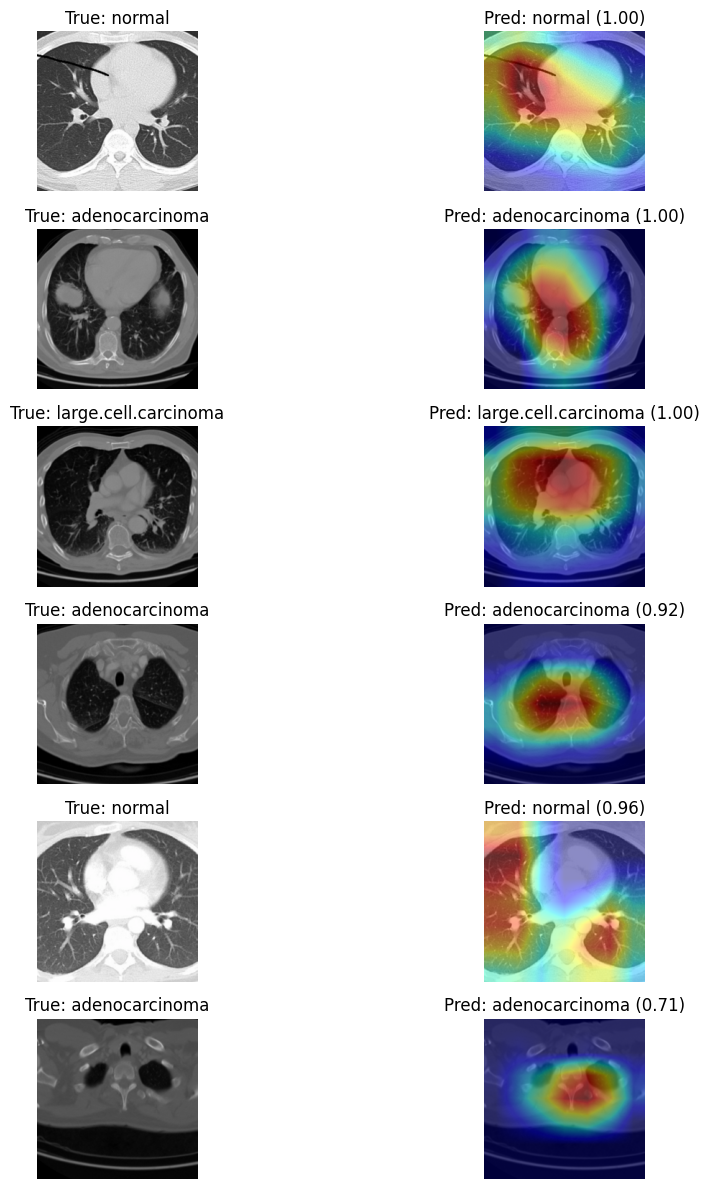

In [14]:
# === Robust Grad-CAM (no new undeclared vars) ===
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# 1) Resolve model from common variable names or by type
def _resolve_model():
    candidates = [
        'modelft','model','net','resnet','resnet18','clf','cnn'
    ]
    for name in candidates:
        if name in globals():
            obj = globals()[name]
            if hasattr(obj, 'parameters'):
                return obj, name
    # As a last resort, scan globals for a torch.nn.Module
    for name, obj in globals().items():
        if isinstance(obj, nn.Module):
            return obj, name
    raise NameError("No model-like variable found (expected e.g., 'modelft' or 'model').")

model, _model_varname = _resolve_model()

# 2) Resolve device; prefer model's current device, else CUDA if available
def _resolve_device(m):
    try:
        dev = next(m.parameters()).device
    except StopIteration:
        dev = torch.device('cpu')
    if dev.type == 'cpu' and torch.cuda.is_available():
        return torch.device('cuda')
    return dev

device = _resolve_device(model)
model.to(device).eval()

# 3) Resolve a dataloader (test/val/train) from common names
def _resolve_loader():
    # dict-style dataloaders
    if 'dataloaders' in globals() and isinstance(dataloaders, dict):
        for key in ['test','val','validation','eval','train']:
            if key in dataloaders and dataloaders[key] is not None:
                return dataloaders[key], key
        # fallback to first available
        if len(dataloaders) > 0:
            k = next(iter(dataloaders.keys()))
            return dataloaders[k], k
    # single loader variables
    for name in ['test_loader','val_loader','validation_loader','eval_loader','data_loader','loader_test','loader_val','train_loader']:
        if name in globals():
            return globals()[name], name
    raise NameError("No dataloader found (looked for 'dataloaders', 'test_loader', 'val_loader', etc.).")

loader, _loader_name = _resolve_loader()

# 4) Pull one batch robustly
batch = next(iter(loader))
inputs, labels = None, None
if isinstance(batch, dict):
    inputs = batch.get('images') or batch.get('image') or batch.get('inputs') or next(iter(batch.values()))
    labels = batch.get('labels') or batch.get('label')
elif isinstance(batch, (list, tuple)):
    inputs = batch[0]
    labels = batch[1] if len(batch) > 1 else None
else:
    inputs = batch
if labels is None:
    labels = torch.zeros(len(inputs), dtype=torch.long)
inputs = inputs.to(device)

# 5) Infer class names from dataset or model
def _infer_classnames(m, loader, labels):
    names = None
    if hasattr(loader, 'dataset'):
        ds = loader.dataset
        if hasattr(ds, 'classes') and ds.classes:
            names = list(ds.classes)
        elif hasattr(ds, 'class_to_idx') and ds.class_to_idx:
            names = [k for k, v in sorted(ds.class_to_idx.items(), key=lambda kv: kv[1])]
    if names is None:
        num_classes = None
        # Typical heads
        if hasattr(m, 'fc') and isinstance(m.fc, nn.Linear):
            num_classes = m.fc.out_features
        else:
            # Last Linear module
            last_linear = None
            for mod in m.modules():
                if isinstance(mod, nn.Linear):
                    last_linear = mod
            if last_linear is not None:
                num_classes = last_linear.out_features
        if num_classes is None and labels is not None:
            num_classes = int(torch.max(labels).item()) + 1
        if num_classes is None:
            num_classes = 2
        names = [f"class_{i}" for i in range(num_classes)]
    return names

classnames = _infer_classnames(model, loader, labels)

# 6) Infer normalization from dataset transforms; fallback to ImageNet or 1-channel defaults
def _infer_norm(loader, inputs):
    mean, std = None, None
    ds = getattr(loader, 'dataset', None)
    tfs = None
    for attr in ['transform','transforms','train_transform','val_transform','test_transform']:
        if ds is not None and hasattr(ds, attr):
            tfs = getattr(ds, attr)
            break
    ops = []
    if tfs is not None and hasattr(tfs, 'transforms'):
        ops = tfs.transforms
    elif isinstance(tfs, (list, tuple)):
        ops = list(tfs)
    elif tfs is not None:
        ops = [tfs]
    for op in ops:
        if hasattr(op, 'mean') and hasattr(op, 'std'):
            mean = op.mean
            std = op.std
            if isinstance(mean, torch.Tensor): mean = mean.tolist()
            if isinstance(std, torch.Tensor): std = std.tolist()
            break
    C = inputs.shape[1]
    if mean is None or std is None:
        if C == 1:
            mean, std = [0.5], [0.5]
        else:
            mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    mean = torch.tensor(mean, device=device).view(1, -1, 1, 1)
    std = torch.tensor(std, device=device).view(1, -1, 1, 1)
    return mean, std

IM_MEAN, IM_STD = _infer_norm(loader, inputs)

# 7) Find the last Conv2d layer if a specific layer is not known
def _find_last_conv2d(m):
    last = None
    for mod in m.modules():
        if isinstance(mod, nn.Conv2d):
            last = mod
    if last is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM.")
    return last

target_layer = _find_last_conv2d(model)

# 8) Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._fh = self.target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output
        def _save_grad(grad):
            self.gradients = grad
        output.register_hook(_save_grad)

    def remove_hooks(self):
        if hasattr(self, "_fh") and self._fh is not None:
            self._fh.remove()
            self._fh = None

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(logits, dim=1)
        one_hot = torch.zeros_like(logits)
        one_hot[torch.arange(x.size(0), device=logits.device), class_idx] = 1.0
        loss = torch.sum(one_hot * logits)
        self.model.zero_grad(set_to_none=True)
        loss.backward(retain_graph=True)

        grads = self.gradients          # [N,C,H,W]
        acts = self.activations         # [N,C,H,W]
        weights = grads.mean(dim=(2,3), keepdim=True)      # [N,C,1,1]
        cam = F.relu((weights * acts).sum(dim=1, keepdim=True))  # [N,1,H,W]
        # Normalize per-sample
        N = cam.size(0)
        cam = cam.view(N, -1)
        cam_min = cam.min(dim=1, keepdim=True)[0]
        cam_max = cam.max(dim=1, keepdim=True)[0]
        cam = ((cam - cam_min) / (cam_max - cam_min + 1e-8)).view(N, 1, acts.size(2), acts.size(3))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)

        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        return cam, class_idx, probs, preds

# 9) Run Grad-CAM on a small batch
gradcam = GradCAM(model, target_layer)
cams, class_idx, probs, preds = gradcam(inputs)

# 10) Visualization helpers
def _to_numpy_img(t):
    # t: [3,H,W] or [1,H,W]; denormalize with inferred stats
    if t.dim() == 3:
        t = t.unsqueeze(0)
    t = t * IM_STD + IM_MEAN
    t = t.clamp(0, 1)
    t = t.detach().cpu().squeeze(0)      # [C,H,W]
    if t.size(0) == 1:
        t = t.repeat(3, 1, 1)            # tile for display
    t = t.permute(1, 2, 0).numpy()       # HWC
    return t

def _overlay(img, cam, alpha=0.45, cmap='jet'):
    import matplotlib.cm as cm
    cam = np.clip(cam, 0, 1)
    color_map = cm.get_cmap(cmap)
    cam_rgb = color_map(cam)[:, :, :3]
    out = (1 - alpha) * img + alpha * cam_rgb
    return np.clip(out, 0, 1)

# 11) Show a few images with overlays
n_show = min(6, inputs.size(0))
plt.figure(figsize=(12, 2 * n_show))
for i in range(n_show):
    img = _to_numpy_img(inputs[i])
    cam_map = cams[i, 0].detach().cpu().numpy()
    overlay = _overlay(img, cam_map, alpha=0.45, cmap='jet')

    plt.subplot(n_show, 2, 2*i + 1)
    plt.imshow(img)
    plt.axis('off')
    tlabel = int(labels[i].item()) if labels is not None else -1
    tname = classnames[tlabel] if 0 <= tlabel < len(classnames) else str(tlabel)
    plt.title(f"True: {tname}")

    plt.subplot(n_show, 2, 2*i + 2)
    plt.imshow(overlay)
    plt.axis('off')
    conf = probs[i, preds[i]].item()
    pname = classnames[int(preds[i].item())] if int(preds[i].item()) < len(classnames) else str(int(preds[i].item()))
    plt.title(f"Pred: {pname} ({conf:.2f})")

plt.tight_layout()
gradcam.remove_hooks()


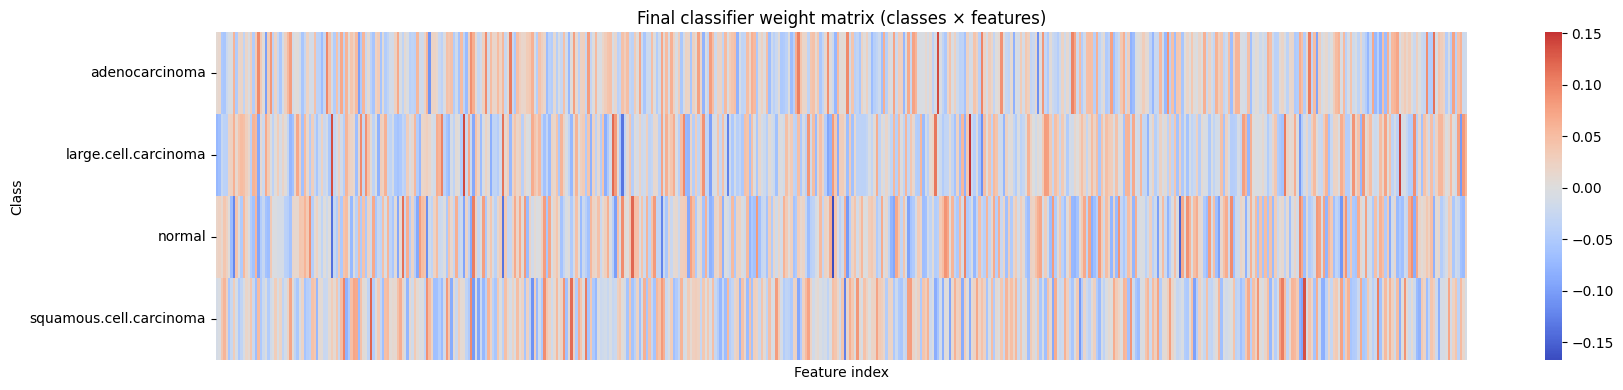

Per-class L2 norms:
  adenocarcinoma: 0.9698
  large.cell.carcinoma: 1.0324
  normal: 1.1239
  squamous.cell.carcinoma: 1.0279
Saved: final_classifier_weights.csv and final_classifier_weights.npy


In [15]:
# === Final-layer weight matrix (robust) ===
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Optional seaborn
try:
    import seaborn as sns
    _HAVE_SNS = True
except Exception:
    _HAVE_SNS = False

# Optional pandas
try:
    import pandas as pd
    _HAVE_PANDAS = True
except Exception:
    _HAVE_PANDAS = False

# Resolve model again in a standalone way
def _resolve_model():
    candidates = ['modelft','model','net','resnet','resnet18','clf','cnn']
    for name in candidates:
        if name in globals():
            obj = globals()[name]
            if hasattr(obj, 'parameters'):
                return obj, name
    for name, obj in globals().items():
        if isinstance(obj, nn.Module):
            return obj, name
    raise NameError("No model-like variable found.")

model, _model_varname = _resolve_model()

# Find the final linear classifier layer
def _find_classifier_linear(m):
    if hasattr(m, 'fc') and isinstance(m.fc, nn.Linear):
        return m.fc
    for attr in ['classifier','head','heads','last_linear','final_fc']:
        if hasattr(m, attr):
            mod = getattr(m, attr)
            if isinstance(mod, nn.Linear):
                return mod
            if isinstance(mod, nn.Sequential):
                for sub in reversed(mod):
                    if isinstance(sub, nn.Linear):
                        return sub
    # fallback: last Linear in the module tree
    last_linear = None
    for sub in m.modules():
        if isinstance(sub, nn.Linear):
            last_linear = sub
    if last_linear is None:
        raise RuntimeError("No Linear layer found to represent the classifier head.")
    return last_linear

head = _find_classifier_linear(model)

# Resolve a loader to infer class names if available
def _resolve_loader():
    if 'dataloaders' in globals() and isinstance(dataloaders, dict) and len(dataloaders) > 0:
        # prefer test/val
        for key in ['test','val','validation','eval','train']:
            if key in dataloaders and dataloaders[key] is not None:
                return dataloaders[key], key
        return dataloaders[next(iter(dataloaders.keys()))], next(iter(dataloaders.keys()))
    for name in ['test_loader','val_loader','validation_loader','eval_loader','data_loader','loader_test','loader_val','train_loader']:
        if name in globals():
            return globals()[name], name
    return None, None

loader, _loader_name = _resolve_loader()

# Infer class names
def _infer_classnames_from_loader_or_head(loader, head):
    names = None
    if loader is not None and hasattr(loader, 'dataset'):
        ds = loader.dataset
        if hasattr(ds, 'classes') and ds.classes:
            names = list(ds.classes)
        elif hasattr(ds, 'class_to_idx') and ds.class_to_idx:
            names = [k for k, v in sorted(ds.class_to_idx.items(), key=lambda kv: kv[1])]
    if names is None:
        num_classes = getattr(head, 'out_features', None)
        if num_classes is None:
            num_classes = 2
        names = [f"class_{i}" for i in range(int(num_classes))]
    return names

classnames = _infer_classnames_from_loader_or_head(loader, head)

# Extract weights and bias
with torch.no_grad():
    W = head.weight.detach().cpu().numpy()  # [num_classes, feat_dim]
    b = head.bias.detach().cpu().numpy() if head.bias is not None else None

# Plot heatmap
plt.figure(figsize=(18, 4))
if _HAVE_SNS:
    import seaborn as sns
    sns.heatmap(W, cmap="coolwarm", center=0, cbar=True,
                xticklabels=False, yticklabels=classnames)
else:
    vmax = float(np.max(np.abs(W)))
    plt.imshow(W, cmap="coolwarm", aspect='auto', vmin=-vmax, vmax=vmax)
    plt.yticks(np.arange(len(classnames)), classnames)
    plt.colorbar()
plt.title("Final classifier weight matrix (classes × features)")
plt.xlabel("Feature index")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

# Per-class L2 norms
norms = np.linalg.norm(W, axis=1)
print("Per-class L2 norms:")
for cname, n in zip(classnames, norms):
    print(f"  {cname}: {n:.4f}")

# Save CSV/NPY
if _HAVE_PANDAS:
    df = pd.DataFrame(W, index=classnames, columns=[f"f{i}" for i in range(W.shape[1])])
    df.to_csv("final_classifier_weights.csv", index=True)
else:
    np.savetxt("final_classifier_weights.csv", W, delimiter=",")
np.save("final_classifier_weights.npy", W)
print("Saved: final_classifier_weights.csv and final_classifier_weights.npy")
